# STEP 0: SETUP

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import f1_score
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import math
import random
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Cấu hình tham số cơ bản
IMAGE_SIZE = [224, 224] # Dùng kích thước 224x224
BATCH_SIZE = 32
AUTO = tf.data.AUTOTUNE

EDA_PATH = "/kaggle/input/competitions/tpu-getting-started/tfrecords-jpeg-192x192"
EDA_FILENAMES = tf.io.gfile.glob(EDA_PATH + '/train/*.tfrec')

DS_PATH = "/kaggle/input/competitions/tpu-getting-started/tfrecords-jpeg-224x224"
TRAIN_FILENAMES = tf.io.gfile.glob(DS_PATH + '/train/*.tfrec')
VAL_FILENAMES = tf.io.gfile.glob(DS_PATH + '/val/*.tfrec')
TEST_FILENAMES = tf.io.gfile.glob(DS_PATH + '/test/*.tfrec')

# STEP 1: EDA

In [2]:
FEATURE_DESCRIPTION = {
    "image": tf.io.FixedLenFeature([], tf.string),
    "class": tf.io.FixedLenFeature([], tf.int64)
}

def parse_tfrecord(example):
    example = tf.io.parse_single_example(example, FEATURE_DESCRIPTION)

    image = tf.io.decode_jpeg(example['image'], channels=3)
    image = tf.cast(image, tf.float32) / 255.0

    label = tf.cast(example['class'], tf.int32)
    return image,label

def load_dataset(filenames):
    dataset = tf.data.TFRecordDataset(filenames)
    dataset = dataset.map(parse_tfrecord)
    return dataset

eda_ds = load_dataset(EDA_FILENAMES)

I0000 00:00:1789744466.682495      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789744466.685316      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


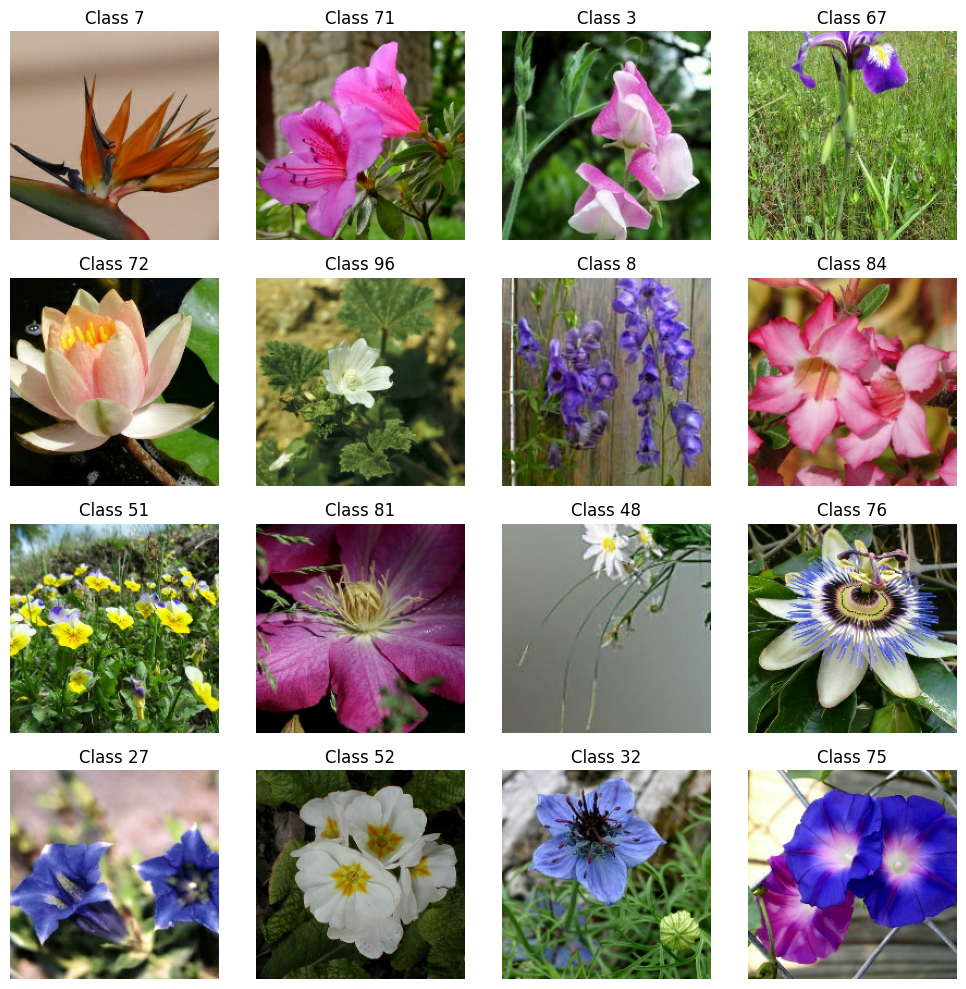

In [3]:
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(eda_ds.take(16)):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(image.numpy())
    
    # Lấy tên lớp nếu có danh sách CLASSES, nếu không thì hiện ID
    class_id = label.numpy()
    plt.title(f"Class {class_id}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
def parse_label_only(example):
    feature = {"class": tf.io.FixedLenFeature([], tf.int64)}
    parsed = tf.io.parse_single_example(example, feature)
    return parsed["class"]

# Load danh sách nhãn
label_ds = tf.data.TFRecordDataset(EDA_FILENAMES).map(parse_label_only)
labels = [l.numpy() for l in label_ds]

# 2. Tạo DataFrame nhóm theo Class
df_stats = pd.DataFrame({'class_id': labels})
class_counts = df_stats['class_id'].value_counts().sort_index().reset_index()
class_counts.columns = ['class_id', 'count']

# 3. Tính toán các chỉ số quan trọng
total_samples = len(labels)
num_classes = class_counts['class_id'].nunique()
min_count = class_counts['count'].min()
max_count = class_counts['count'].max()
mean_count = class_counts['count'].mean()
median_count = class_counts['count'].median()
imbalance_ratio = max_count / min_count

print(f"--- THỐNG KÊ TẬP TRAIN ---")
print(f"Tổng số ảnh: {total_samples}")
print(f"Tổng số lớp: {num_classes}")
print(f"Số lượng ít nhất ở 1 lớp: {min_count}")
print(f"Số lượng nhiều nhất ở 1 lớp: {max_count}")
print(f"Trung bình / Trung vị mỗi lớp: {mean_count:.1f} / {median_count:.1f}")
print(f"Tỷ lệ mất cân bằng (Max/Min): {imbalance_ratio:.2f}x")

--- THỐNG KÊ TẬP TRAIN ---
Tổng số ảnh: 12753
Tổng số lớp: 104
Số lượng ít nhất ở 1 lớp: 18
Số lượng nhiều nhất ở 1 lớp: 782
Trung bình / Trung vị mỗi lớp: 122.6 / 88.0
Tỷ lệ mất cân bằng (Max/Min): 43.44x


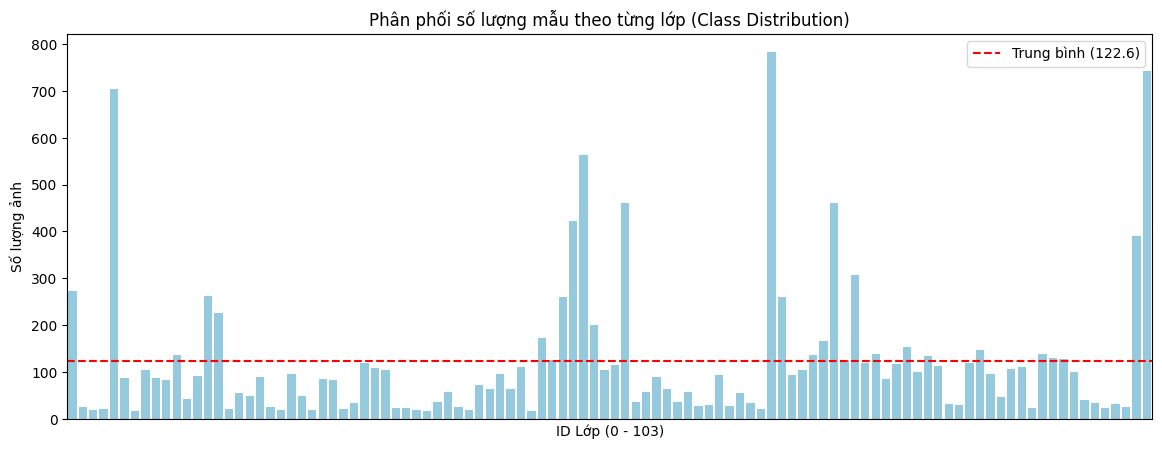

In [5]:
plt.figure(figsize=(14, 5))
sns.barplot(data=class_counts, x='class_id', y='count', color='skyblue')
plt.axhline(mean_count, color='red', linestyle='--', label=f'Trung bình ({mean_count:.1f})')
plt.title("Phân phối số lượng mẫu theo từng lớp (Class Distribution)")
plt.xlabel("ID Lớp (0 - 103)")
plt.ylabel("Số lượng ảnh")
plt.xticks([])  # Ẩn nhãn trục X cho gọn vì có 104 lớp
plt.legend()
plt.show()

# STEP 2: PREPROCESSING

In [6]:
# Tự động trích xuất các nhãn yếu (< 50 mẫu) dựa vào kết quả EDA ở STEP 1
RARE_CLASSES = class_counts[class_counts['count'] < 50]['class_id'].tolist()
RARE_CLASSES_TENSOR = tf.constant(RARE_CLASSES, dtype=tf.int32)

def decode_image(image_data):
    image = tf.io.decode_jpeg(image_data, channels=3)
    image = tf.cast(image, tf.float32) / 255.0  # Chuẩn hóa pixel về [0, 1]
    image = tf.reshape(image, [*IMAGE_SIZE, 3])
    return image

def read_labeled_tfrecord(example):
    LABELED_TFREC_FORMAT = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "class": tf.io.FixedLenFeature([], tf.int64),
    }
    example = tf.io.parse_single_example(example, LABELED_TFREC_FORMAT)
    image = decode_image(example['image'])
    label = tf.cast(example['class'], tf.int32)
    return image, label

def read_unlabeled_tfrecord(example):
    UNLABELED_TFREC_FORMAT = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "id": tf.io.FixedLenFeature([], tf.string),
    }
    example = tf.io.parse_single_example(example, UNLABELED_TFREC_FORMAT)
    image = decode_image(example['image'])
    idnum = example['id']
    return image, idnum

# Augmentation tiêu chuẩn
def data_augment_basic(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    return image, label

# Augmentation mạnh mẽ dành riêng cho các nhãn yếu
def data_augment_strong(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    return image, label

def conditional_augmentation(image, label):
    is_rare = tf.reduce_any(tf.equal(label, RARE_CLASSES_TENSOR))
    image, label = tf.cond(
        is_rare,
        lambda: data_augment_strong(image, label),
        lambda: data_augment_basic(image, label)
    )
    return image, label

# Khởi tạo Pipeline dữ liệu hoàn chỉnh
def get_training_dataset():
    dataset = tf.data.TFRecordDataset(TRAIN_FILENAMES, num_parallel_reads=AUTO)
    dataset = dataset.map(read_labeled_tfrecord, num_parallel_calls=AUTO)
    dataset = dataset.map(conditional_augmentation, num_parallel_calls=AUTO)
    dataset = dataset.repeat().shuffle(2048).batch(BATCH_SIZE).prefetch(AUTO)
    return dataset

def get_validation_dataset():
    dataset = tf.data.TFRecordDataset(VAL_FILENAMES, num_parallel_reads=AUTO)
    dataset = dataset.map(read_labeled_tfrecord, num_parallel_calls=AUTO)
    dataset = dataset.batch(BATCH_SIZE).cache().prefetch(AUTO)
    return dataset

def get_test_dataset():
    dataset = tf.data.TFRecordDataset(TEST_FILENAMES, num_parallel_reads=AUTO)
    dataset = dataset.map(read_unlabeled_tfrecord, num_parallel_calls=AUTO)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTO)
    return dataset

train_ds = get_training_dataset()
val_ds = get_validation_dataset()
test_ds = get_test_dataset()

# STEP 3: MODEL BUILDING & COMPILATION

In [7]:
class CustomSparseCategoricalFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, name='custom_sparse_focal_loss'):
        super().__init__(name=name)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        
        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(y_true, depth=num_classes)
        
        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)
        cross_entropy = -tf.math.log(p_t)
        
        loss = focal_weight * cross_entropy
        return tf.reduce_mean(loss)

def build_model(num_classes=104):
    # Khai báo Pretrained Model (EfficientNetB0)
    base_model = tf.keras.applications.EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=[*IMAGE_SIZE, 3]
    )
    base_model.trainable = True

    # Custom Logits Classifier Head
    inputs = layers.Input(shape=[*IMAGE_SIZE, 3])
    x = base_model(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

model = build_model()

# 2. Khởi tạo Custom Focal Loss
focal_loss = CustomSparseCategoricalFocalLoss(gamma=2.0)

# 3. Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=focal_loss,
    metrics=['sparse_categorical_accuracy']
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# STEP 4: TRAINING & EVALUATION (METRIC)

In [8]:
class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, val_dataset):
        super().__init__()
        self.val_dataset = val_dataset

    def on_epoch_end(self, epoch, logs=None):
        val_images = self.val_dataset.map(lambda image, label: image)
        val_labels = self.val_dataset.map(lambda image, label: label)
        
        y_true = np.concatenate([label.numpy() for label in val_labels], axis=0)
        preds = self.model.predict(val_images, verbose=0)
        y_pred = np.argmax(preds, axis=1)
        
        score = f1_score(y_true, y_pred, average='macro')
        print(f" — val_macro_f1: {score:.4f}")

STEPS_PER_EPOCH = total_samples // BATCH_SIZE

# Huấn luyện mô hình
history = model.fit(
    train_ds,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=15,
    validation_data=val_ds,
    callbacks=[
        MacroF1Callback(val_ds),
        tf.keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss')
    ]
)

Epoch 1/15


2026-09-18 15:15:28.132985: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 15:15:28.277662: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 15:15:28.626801: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 15:15:28.770100: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 15:15:28.912088: E external/local_xla/xla/stream_

398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 3.8133 - sparse_categorical_accuracy: 0.1824

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


 — val_macro_f1: 0.0045
398/398 ━━━━━━━━━━━━━━━━━━━━ 159s 185ms/step - loss: 2.8736 - sparse_categorical_accuracy: 0.3387 - val_loss: 4.5917 - val_sparse_categorical_accuracy: 0.0469
Epoch 2/15
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 1.4026 - sparse_categorical_accuracy: 0.6176

...

 — val_macro_f1: 0.3474
398/398 ━━━━━━━━━━━━━━━━━━━━ 59s 148ms/step - loss: 0.0695 - sparse_categorical_accuracy: 0.9631 - val_loss: 1.9528 - val_sparse_categorical_accuracy: 0.4612
Epoch 14/15
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0671 - sparse_categorical_accuracy: 0.9633

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


 — val_macro_f1: 0.6190
398/398 ━━━━━━━━━━━━━━━━━━━━ 59s 147ms/step - loss: 0.0611 - sparse_categorical_accuracy: 0.9664 - val_loss: 1.0532 - val_sparse_categorical_accuracy: 0.6662
Epoch 15/15
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0529 - sparse_categorical_accuracy: 0.9709

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


 — val_macro_f1: 0.1320
398/398 ━━━━━━━━━━━━━━━━━━━━ 59s 148ms/step - loss: 0.0523 - sparse_categorical_accuracy: 0.9721 - val_loss: 3.1199 - val_sparse_categorical_accuracy: 0.2419


# STEP 5: SUBMISSION

In [9]:
# 1. Tải trọng số mô hình tốt nhất
model.load_weights('best_model.h5')

# 2. Dự đoán trên tập Test
test_images_ds = test_ds.map(lambda image, idnum: image)
predictions = model.predict(test_images_ds)
probabilities = np.argmax(predictions, axis=-1)

# 3. Lấy danh sách ID tương ứng
test_ids_ds = test_ds.map(lambda image, idnum: idnum).unbatch()
test_ids = [idnum.numpy().decode('utf-8') for idnum in test_ids_ds]

# 4. Xuất CSV nộp bài Kaggle
sub_df = pd.DataFrame({'id': test_ids, 'label': probabilities})
sub_df.to_csv('submission.csv', index=False)

print("Đã tạo thành công file submission.csv!")
sub_df.head()

    229/Unknown 8s 33ms/step

2026-09-18 15:31:18.448368: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 15:31:18.591128: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 15:31:18.932573: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 15:31:19.074971: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 15:31:19.862445: E external/local_xla/xla/stream_

231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Đã tạo thành công file submission.csv!


,id,label
0,59d1b6146,46
1,aeb67eefb,52
2,48c96bd6b,77
3,2213dd7ad,25
4,7b437ba4e,49
